**# Laboratorio 5**
* Brayan Rivera Navarro C26477
* Gael Alpízar Alfaro C20270
* Erick Hernández Hernández C23744
* Nathalia Chaves Oviedo C22195

Primero importamos las librerias necesarias para el laboratorio, incluyendo las usadas para el análisis inicial de los conjuntos de datos, y traemos los archivos csv guardados en drive.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
concentricos = pd.read_csv('/content/drive/MyDrive/circulos_concentricos.csv')
dispersos = pd.read_csv('/content/drive/MyDrive/clusters_dispersos.csv')
lunas = pd.read_csv('/content/drive/MyDrive/lunas.csv')

## Topología de los datos
Ahora usamos métodos info() y head() para ver las características de cada conjuntos de datos, incluyendo la cantidad de entradas de cada uno, las columnas que tienen y los tipos de datos que manejan.


In [3]:
concentricos.info()
display(concentricos.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  300 non-null    float64
 1   Feature2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


,Feature1,Feature2
0,-0.205549,0.441302
1,0.291795,-0.487135
2,0.385734,0.039077
3,0.852735,0.446299
4,-0.468830,-0.175415


In [4]:
dispersos.info()
display(dispersos.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  300 non-null    float64
 1   Feature2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


,Feature1,Feature2
0,-7.247116,-7.559985
1,-7.567958,-7.187754
2,-1.851162,8.037611
3,4.465734,2.852191
4,-8.510127,-7.686579


In [5]:
lunas.info()
display(lunas.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  300 non-null    float64
 1   Feature2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


,Feature1,Feature2
0,0.622519,-0.372101
1,1.904269,-0.136303
2,-0.069431,0.456117
3,0.933899,0.237483
4,1.180360,-0.490847


Como siguiente paso graficamos los conjuntos de datos usando matplotlib, que nos permite ver mediante un gráfico de dispersión como de distribuyen los datos y nos muestra la estructura de cada uno.

Como se puede ver para el caso de los círculos concentricos se puede ver una estructura bien definida, con los datos acomodados formando 2 círculos, uno interno y otro externo, aunque presenta algunas anomalias que se encuentran fuera de los círculos principales.

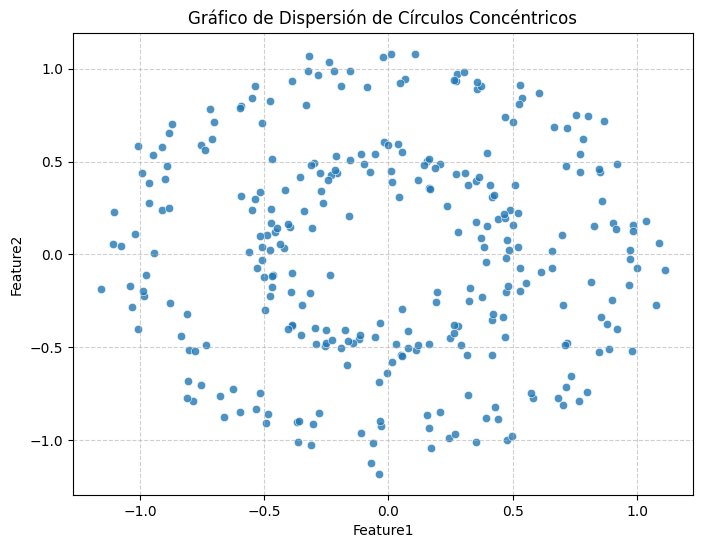

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Feature1', y='Feature2', data=concentricos, alpha=0.8)
plt.title('Gráfico de Dispersión de Círculos Concéntricos')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

En cuanto al gráfico de dispersión del dataset de clusters dispersos se aprecia como los datos se agrupan en 3 conjuntos principales, 2 siendo bastante compactos mientras que el tercero tiene sus datos un tanto más dispersos.

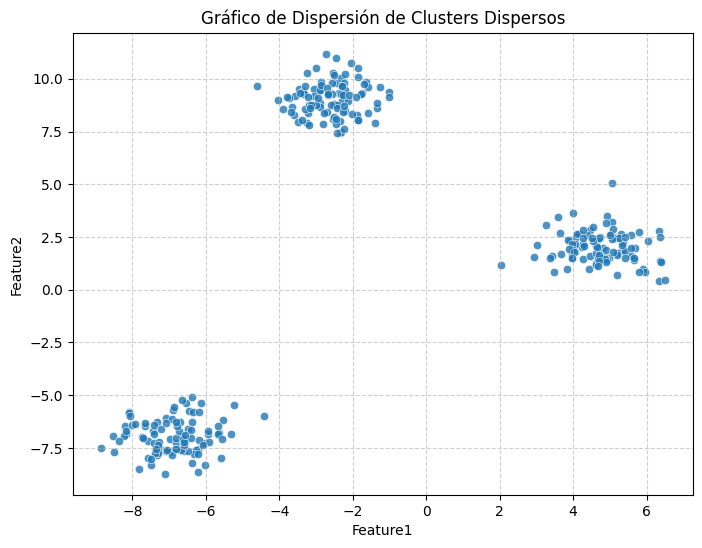

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Feature1', y='Feature2', data=dispersos, alpha=0.8)
plt.title('Gráfico de Dispersión de Clusters Dispersos')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

FInalmente el gráfico de dispersión de lunas muestra como los valores se agrupan formando 2 medias lunas, representando una topología no lineal.

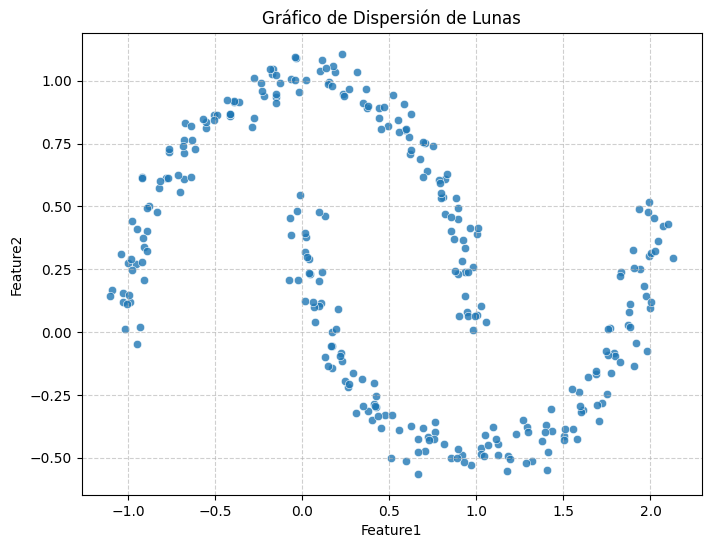

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Feature1', y='Feature2', data=lunas, alpha=0.8)
plt.title('Gráfico de Dispersión de Lunas')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Normalización de los datasets
Ahora pasamos a normalizar los datos utilizando minmaxscaler para que todos se encuentren en una misma escala, esto para que los calculos basados en distancia como k-means no se vean afectados por variables que son demasiado grandes en comparación con otras, ya que si se normalizan, métodos que se basan en las distancia entre los puntos para crear los clusters se ven sesgados por los valores muy grandes, quitandole importancia a los datos más pequeños y agrupando basandose en las magnitud de los datos en lugar de su similitud.

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

concentricos_scaled = scaler.fit_transform(concentricos[['Feature1', 'Feature2']])
concentricos_scaled_df = pd.DataFrame(concentricos_scaled, columns=['Feature1_scaled', 'Feature2_scaled'])

display(concentricos_scaled_df.head())


,Feature1_scaled,Feature2_scaled
0,0.419189,0.717152
1,0.638518,0.306522
2,0.679945,0.539256
3,0.885893,0.719363
4,0.303082,0.444390


In [10]:
dispersos_scaled = scaler.fit_transform(dispersos[['Feature1', 'Feature2']])
dispersos_scaled_df = pd.DataFrame(dispersos_scaled, columns=['Feature1_scaled', 'Feature2_scaled'])

display(dispersos_scaled_df.head())

,Feature1_scaled,Feature2_scaled
0,0.104885,0.058340
1,0.083981,0.077033
2,0.456446,0.841663
3,0.868009,0.581247
4,0.022596,0.051982


In [11]:
lunas_scaled = scaler.fit_transform(lunas[['Feature1', 'Feature2']])
lunas_scaled_df = pd.DataFrame(lunas_scaled, columns=['Feature1_scaled', 'Feature2_scaled'])

display(lunas_scaled_df.head())

,Feature1_scaled,Feature2_scaled
0,0.533763,0.114382
1,0.929871,0.255494
2,0.319925,0.610023
3,0.629991,0.479183
4,0.706156,0.043320


## Algoritmo K-means
Una vez tenemos los datos normalizados pasamos a aplicar primero el algoritmo de kmeans a los datasets, este algoritmo crea los k clusters haciendo que los puntos de cada grupo estén lo más cerca posible a su centroide, de modo que al inicio se asignan los puntos al centroide más cercano y posteriormente se van recalculando los centroides como la media de los puntos que pertenecen a ese cluster, hasta que ya no cambien.

Este algoritmo no suele funcionar muy bien en formas concavas o densidades irregulares ya que por defecto asume que los clusters son circulares al rededor del centroide, cosa que no pasa en casos como los circulos concentricos o las lunas, en donde los datos no se agrupan al rededor de un centro como tal sino en formas curvadas basandose en la densidad de los grupos.

## K-means para círculos concéntricos
Primero aplicamos el algoritmo para el dataset de círculos concéntricos, definimos el modelo con 2 clusters, uno para cada anillo, luego usando .fit() se entrena el modelo buscando los centroides como se explicó anteriormente, finalmente se obtienen las etiquetas asignadas a cada punto con .labels_, asi como las coordenadas de los centroides resultantes con .cluster_centers_, y se muestra un nuevo gráfico de dispersión para ver los resultados.
Como se puede ver en el gráfico el algoritmo no fue tan efectivo ya que no agrupo los valores siguiendo los círculos, sino que dividió el plano por la mitad, con un cluster a la izquierda y otro a la derecha.

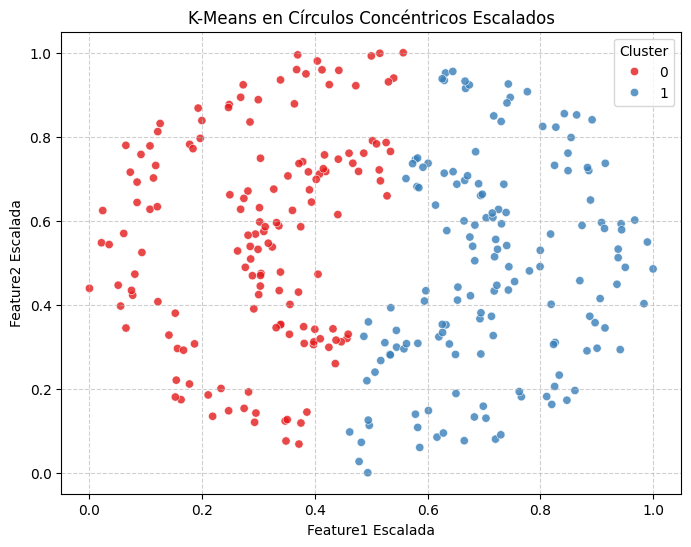

In [12]:
from sklearn.cluster import KMeans

kmeans_concentricos = KMeans(n_clusters=2, random_state=42)
kmeans_labels_concentricos = kmeans_concentricos.fit_predict(concentricos_scaled_df[['Feature1_scaled', 'Feature2_scaled']])
concentricos_scaled_df['Cluster'] = kmeans_labels_concentricos

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Feature1_scaled',
    y='Feature2_scaled',
    hue='Cluster',
    data=concentricos_scaled_df,
    palette='Set1',
    alpha=0.8
)
plt.title('K-Means en Círculos Concéntricos Escalados')
plt.xlabel('Feature1 Escalada')
plt.ylabel('Feature2 Escalada')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## K-means para clusters dispersos
Para el caso de los clusters dispersos se sigue el mismo proceso que en los círculos dispersos, solo que se asignan 3 clusters al modelo para seguir la separación inicial del dataset. Como se puede ver en este caso k-means si dividió los clusters correctamente, agrupandolos en 3 grupos bien divididos en cuanto a distancia.

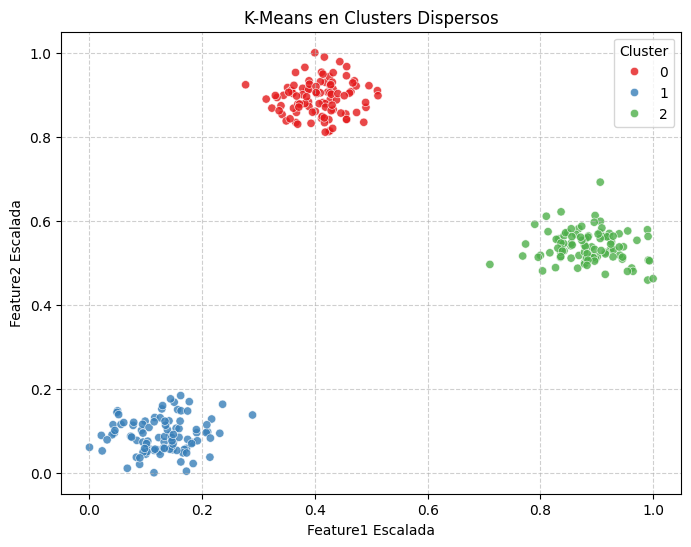

In [13]:
from sklearn.cluster import KMeans

kmeans_dispersos = KMeans(n_clusters=3, random_state=42)
kmeans_labels_dispersos = kmeans_dispersos.fit_predict(dispersos_scaled_df[['Feature1_scaled', 'Feature2_scaled']])
dispersos_scaled_df['Cluster'] = kmeans_labels_dispersos

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Feature1_scaled',
    y='Feature2_scaled',
    hue='Cluster',
    data=dispersos_scaled_df,
    palette='Set1',
    alpha=0.8
)
plt.title('K-Means en Clusters Dispersos')
plt.xlabel('Feature1 Escalada')
plt.ylabel('Feature2 Escalada')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## K-means para lunas
Para el dataset de lunas se vuelven a establecer 2 clusters esperando que k-means haga la división de cada luna correctamente. Ahora, como se puede ver el gráfico otra vez k-means no fue muy efectivo por la forma concava del dataset, mezclando los puntos de ambas lunas en clusters distintos.

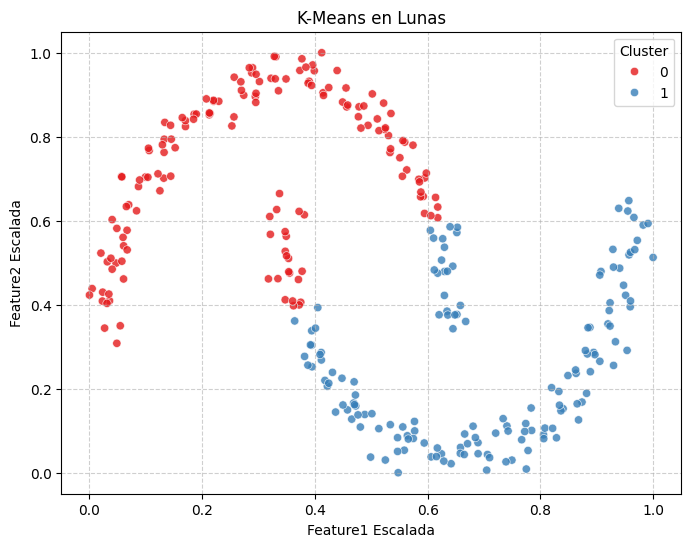

In [14]:
from sklearn.cluster import KMeans

kmeans_lunas = KMeans(n_clusters=2, random_state=42)
kmeans_labels_lunas = kmeans_lunas.fit_predict(lunas_scaled_df[['Feature1_scaled', 'Feature2_scaled']])
lunas_scaled_df['Cluster'] = kmeans_labels_lunas

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Feature1_scaled',
    y='Feature2_scaled',
    hue='Cluster',
    data=lunas_scaled_df,
    palette='Set1',
    alpha=0.8
)
plt.title('K-Means en Lunas')
plt.xlabel('Feature1 Escalada')
plt.ylabel('Feature2 Escalada')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Algoritmo DBSCAN
Este algoritmo a diferencia de k-means, crea los clusters en base a la densidad local de los puntos, por lo que resulta muy útil para datasets como el de circulos concentricos y lunas. Para este algoritmo los hiperparámetros eps y min_samples son muy importantes, eps es el que determina cual es el radio apartir del núcleo del cluster para que los puntos se consideren como vecinos, es decir que entre más grande sea este valor mayor es la distancia válida para que un punto se incluya en el vecindario. Por su parte min_samples determina la densidad que debe tener un cluster para ser considerado como tal, más claramente dice cuántos puntos deben estar dentro del radio de un punto para que este sea considerado como un núcleo. Es decir la combinación de estos párametros determinan cuando un punto es un núcleo de un cluster y cuando es un valor fronterizo que no cumple con el valor mínimo de min_samples.

## Método K-Nearest Neighbors distance plot para círculos concéntricos
Para saber el valor óptimo de eps se usará el método K-Nearest Neighbors distance plot, el cual consiste en calcular la distancia del k-esimo vecino más cercano para cada punto, se ordenan las distancias de menor a mayor y se gráfican, el punto de inflexión en el gráfico es el que usara como posible eps, a continuación se utilizará el método para el dataset de círculos concentricos.

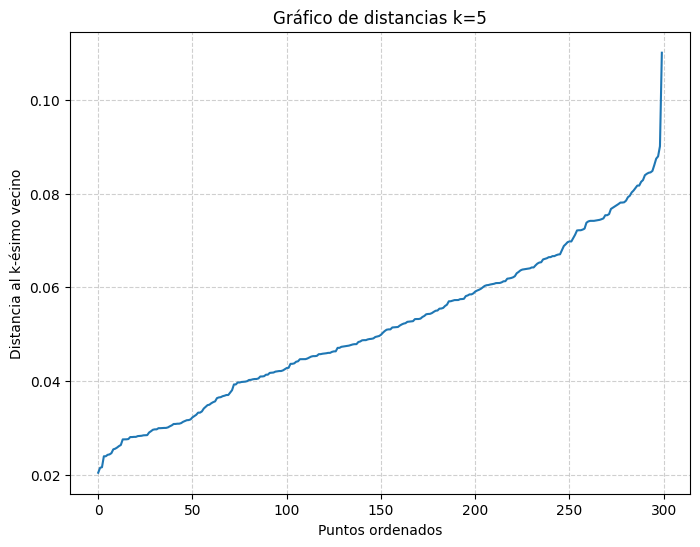

In [15]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(concentricos_scaled_df[['Feature1_scaled','Feature2_scaled']])
distances, indices = neighbors_fit.kneighbors(concentricos_scaled_df[['Feature1_scaled','Feature2_scaled']])
distances_k = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(8,6))
plt.plot(distances_k)
plt.title(f'Gráfico de distancias k={min_samples}')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al k-ésimo vecino')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##DBSCAN para círculos concéntricos
Como mostró el método K-Nearest Neighbors distance plot el valor óptimo para eps en DBSCAN es aproximadamente 0.085, por lo que se usará este dato y un min_samples de 5 para crear el modelo DBSCAN, posteriormente se entrena el modelo con fit_predict() y finalmente se crea el gráfico de dispersión con el resultado. Como podemos ver el algoritmo también tuvo problemas al agrupar ambos círculos aunque lo hizo un poco mejor que k-means agrupando los puntos del círculo interno, se probaron otras combinaciones de eps y min_samples pero no se logró un resultado más óptimo.

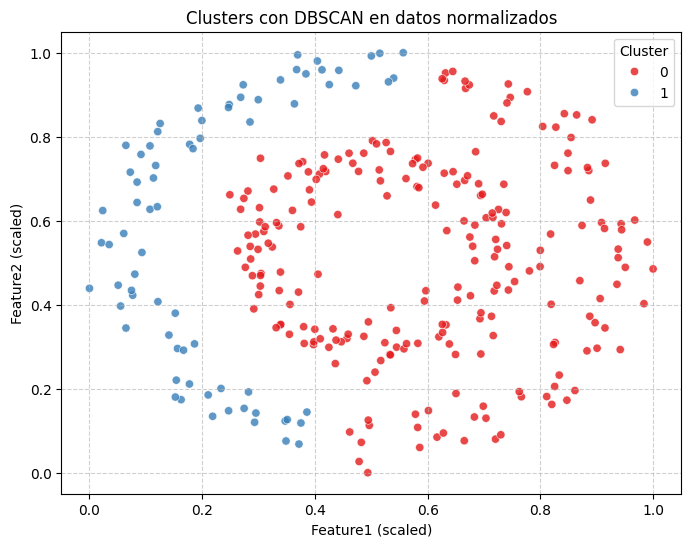

In [16]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.085, min_samples = 5)
dbscan_labels_concentricos = dbscan.fit_predict(concentricos_scaled_df[['Feature1_scaled','Feature2_scaled']])
concentricos_scaled_df['Cluster'] = dbscan_labels_concentricos

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Feature1_scaled',
    y='Feature2_scaled',
    hue='Cluster',
    palette='Set1',
    data=concentricos_scaled_df,
    alpha=0.8
)

plt.title('Clusters con DBSCAN en datos normalizados')
plt.xlabel('Feature1 (scaled)')
plt.ylabel('Feature2 (scaled)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Método K-Nearest Neighbors distance plot clusters dispersos
Ahora se aplica el método K-Nearest Neighbors distance plot para el dataset de clusters dispersos.

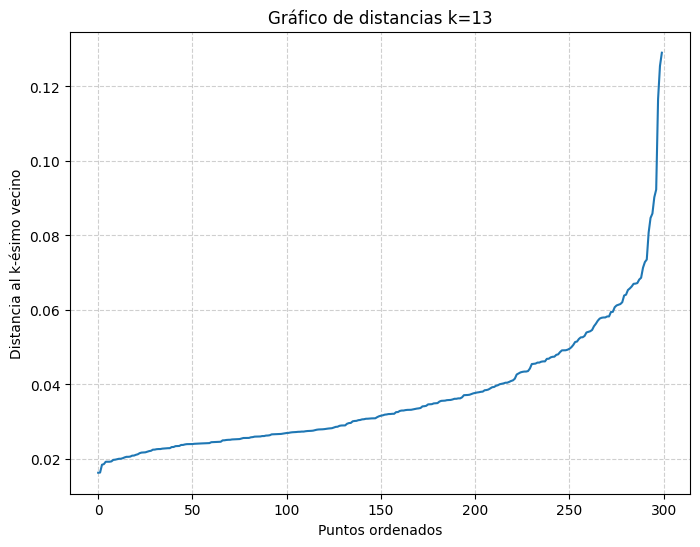

In [17]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

min_samples = 13
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(dispersos_scaled_df[['Feature1_scaled','Feature2_scaled']])
distances, indices = neighbors_fit.kneighbors(dispersos_scaled_df[['Feature1_scaled','Feature2_scaled']])
distances_k = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(8,6))
plt.plot(distances_k)
plt.title(f'Gráfico de distancias k={min_samples}')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al k-ésimo vecino')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##DBSCAN para clusters dispersos
Usando el valor dado por método K-Nearest Neighbors distance plot de aproximadamente 0.08 eps y un min_samples = 13, se ve que DBSCAN fue capaz de agrupar correctamente los 3 clusters que se habían identificado al inicio al mostrar la topología.

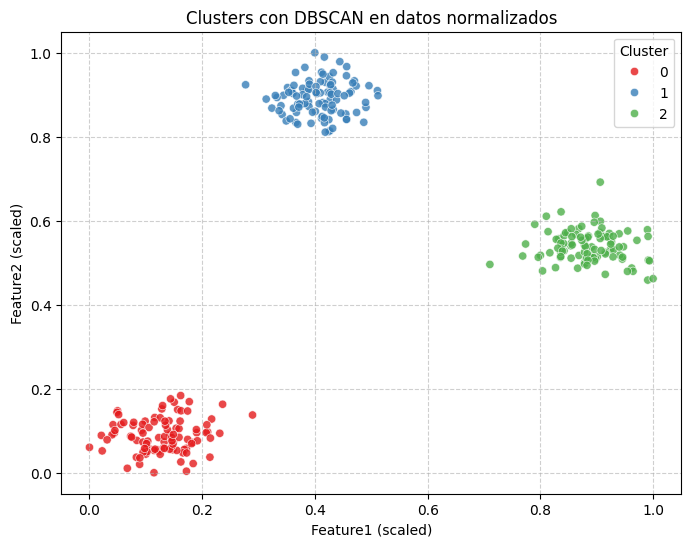

In [18]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.08, min_samples=13)
dbscan_labels_dispersos = dbscan.fit_predict(dispersos_scaled_df[['Feature1_scaled','Feature2_scaled']])
dispersos_scaled_df['Cluster'] = dbscan_labels_dispersos

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Feature1_scaled',
    y='Feature2_scaled',
    hue='Cluster',
    palette='Set1',
    data=dispersos_scaled_df,
    alpha=0.8
)

plt.title('Clusters con DBSCAN en datos normalizados')
plt.xlabel('Feature1 (scaled)')
plt.ylabel('Feature2 (scaled)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Método K-Nearest Neighbors distance plot para lunas
Ahora se aplica el método K-Nearest Neighbors distance plot para el dataset de lunas.

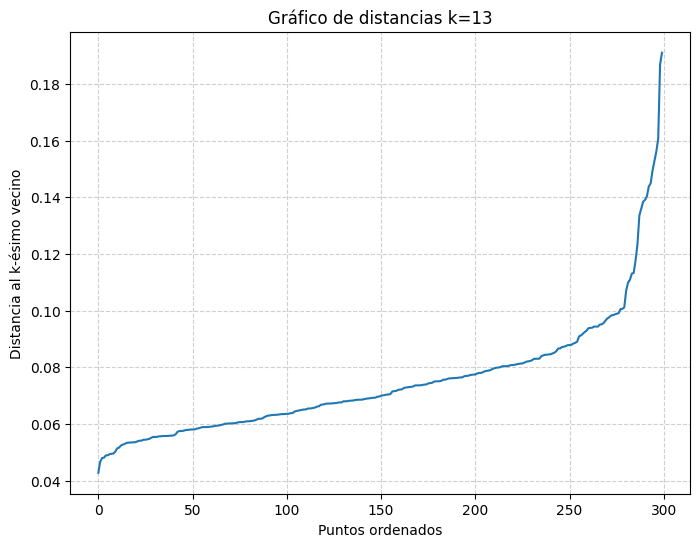

In [19]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

min_samples = 13
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(lunas_scaled_df[['Feature1_scaled','Feature2_scaled']])
distances, indices = neighbors_fit.kneighbors(lunas_scaled_df[['Feature1_scaled','Feature2_scaled']])
distances_k = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(8,6))
plt.plot(distances_k)
plt.title(f'Gráfico de distancias k={min_samples}')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al k-ésimo vecino')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##DBSCAN para lunas
Usando el valor dado por método K-Nearest Neighbors distance plot de aproximadamente 0.1 eps y un min_samples = 13, se ve que DBSCAN fue capaz de agrupar correctamente los puntos de cada luna, cosa que no fue posible usando k-means por la naturaleza del algoritmo.

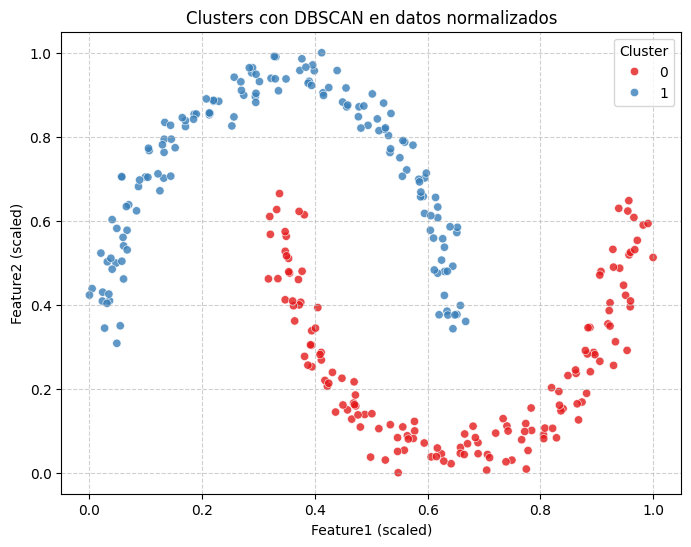

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.1, min_samples=13)
dbscan_labels_lunas = dbscan.fit_predict(lunas_scaled_df[['Feature1_scaled','Feature2_scaled']])
lunas_scaled_df['Cluster'] = dbscan_labels_lunas

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Feature1_scaled',
    y='Feature2_scaled',
    hue='Cluster',
    palette='Set1',
    data=lunas_scaled_df,
    alpha=0.8
)

plt.title('Clusters con DBSCAN en datos normalizados')
plt.xlabel('Feature1 (scaled)')
plt.ylabel('Feature2 (scaled)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##Métodos de evaluación interna
Los métodos de evaluación interna como Silhouette Score y el índice de Davies-Bouldin, nos permiten medir la distribución de los puntos que conforman los clusters, más especificamente el método Silhouette Score nos dice que tan compactos están los puntos del cluster, mientras que el método del índice de Davies-Bouldin mide que tan compacto es un cluster pero también que tan separado está de otros clusters, ambos métodos sirven para evaluar tanto k-means como DBSCAN.

##Métodos de evaluación interna para círculos concéntricos

In [21]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# K-Means
sil_kmeans_concentricos = silhouette_score(concentricos_scaled_df[['Feature1_scaled', 'Feature2_scaled']], kmeans_labels_concentricos)
db_kmeans_concentricos = davies_bouldin_score(concentricos_scaled_df[['Feature1_scaled', 'Feature2_scaled']], kmeans_labels_concentricos)

print("K-Means - Círculos Concéntricos")
print(f"Silhouette Score:     {sil_kmeans_concentricos:.3f}")
print(f"Davies-Bouldin Index: {db_kmeans_concentricos:.3f}")

# DBSCAN
mask_concentricos = dbscan_labels_concentricos != -1

sil_dbscan_concentricos = silhouette_score(concentricos_scaled_df[['Feature1_scaled', 'Feature2_scaled']][mask_concentricos], dbscan_labels_concentricos[mask_concentricos])
db_dbscan_concentricos = davies_bouldin_score(concentricos_scaled_df[['Feature1_scaled', 'Feature2_scaled']][mask_concentricos], dbscan_labels_concentricos[mask_concentricos])

print("\nDBSCAN - Círculos Concéntricos")
print(f"Silhouette Score:     {sil_dbscan_concentricos:.3f}")
print(f"Davies-Bouldin Index: {db_dbscan_concentricos:.3f}")

K-Means - Círculos Concéntricos
Silhouette Score:     0.344
Davies-Bouldin Index: 1.203

DBSCAN - Círculos Concéntricos
Silhouette Score:     0.264
Davies-Bouldin Index: 1.588


### Interpretación - Círculos Concéntricos

K-Means obtuvo un Silhouette Score de 0.344 y un Davies-Bouldin de 1.203.
El Silhouette Score cercano a 0 indica que muchos puntos quedan cerca de la frontera entre clusters, lo cual tiene sentido porque K-Means dividió el plano linealmente en lugar de seguir la forma de los círculos. El Davies-Bouldin alto (1.203) confirma que los clusters no están bien separados ni son compactos.

DBSCAN obtuvo un Silhouette Score de 0.264 y un Davies-Bouldin de 1.588,
peores que K-Means. En este caso DBSCAN tampoco logró separar correctamente los
dos anillos. El KNN distance plot no mostró un codo claro, lo que indica que la
densidad del dataset es muy uniforme y la distancia entre los dos círculos es muy similar a la distancia entre puntos dentro de un mismo círculo. Esto hace que cualquier valor de eps que conecte puntos dentro de un anillo también termine conectando ambos anillos entre sí, haciendo que DBSCAN los fusione en un solo cluster.

Este es un caso donde ninguno de los dos algoritmos es ideal.

##Métodos de evaluación interna para clusters dispersos

In [22]:
# K-Means
sil_kmeans_dispersos = silhouette_score(dispersos_scaled_df[['Feature1_scaled', 'Feature2_scaled']], kmeans_labels_dispersos)
db_kmeans_dispersos = davies_bouldin_score(dispersos_scaled_df[['Feature1_scaled', 'Feature2_scaled']], kmeans_labels_dispersos)

print("K-Means - Clusters Dispersos")
print(f"Silhouette Score:     {sil_kmeans_dispersos:.3f}")
print(f"Davies-Bouldin Index: {db_kmeans_dispersos:.3f}")

# DBSCAN
mask_dispersos = dbscan_labels_dispersos != -1

sil_dbscan_dispersos = silhouette_score(dispersos_scaled_df[['Feature1_scaled', 'Feature2_scaled']][mask_dispersos], dbscan_labels_dispersos[mask_dispersos])
db_dbscan_dispersos = davies_bouldin_score(dispersos_scaled_df[['Feature1_scaled', 'Feature2_scaled']][mask_dispersos], dbscan_labels_dispersos[mask_dispersos])

print("\nDBSCAN - Clusters Dispersos")
print(f"Silhouette Score:     {sil_dbscan_dispersos:.3f}")
print(f"Davies-Bouldin Index: {db_dbscan_dispersos:.3f}")

K-Means - Clusters Dispersos
Silhouette Score:     0.879
Davies-Bouldin Index: 0.169

DBSCAN - Clusters Dispersos
Silhouette Score:     0.879
Davies-Bouldin Index: 0.169


### Interpretación - Clusters Dispersos

K-Means obtuvo un Silhouette Score de 0.879 y un Davies-Bouldin de 0.169.
El Silhouette Score cercano a 1 indica que los puntos están muy bien asignados a su cluster y lejos de los demás. El Davies-Bouldin cercano a 0 confirma que los clusters son compactos y están bien separados entre sí.

Por otro lado, DBSCAN obtuvo exactamente los mismos valores: Silhouette Score de 0.879 y Davies-Bouldin de 0.169. Esto ocurre porque los clusters dispersos tienen una forma aproximadamente esférica y están separados, por lo que ambos algoritmos llegan al mismo resultado correcto.

Este es el único dataset donde las métricas reflejan la calidad del agrupamiento para ambos algoritmos, ya que la topología de los datos es compatible con los supuestos de ambas métricas.

##Métodos de evaluación interna para lunas

In [23]:
# K-Means
sil_kmeans_lunas = silhouette_score(lunas_scaled_df[['Feature1_scaled', 'Feature2_scaled']], kmeans_labels_lunas)
db_kmeans_lunas = davies_bouldin_score(lunas_scaled_df[['Feature1_scaled', 'Feature2_scaled']], kmeans_labels_lunas)

print("K-Means - Lunas")
print(f"Silhouette Score:     {sil_kmeans_lunas:.3f}")
print(f"Davies-Bouldin Index: {db_kmeans_lunas:.3f}")

# DBSCAN
mask_lunas = dbscan_labels_lunas != -1

sil_dbscan_lunas = silhouette_score(lunas_scaled_df[['Feature1_scaled', 'Feature2_scaled']][mask_lunas], dbscan_labels_lunas[mask_lunas])
db_dbscan_lunas = davies_bouldin_score(lunas_scaled_df[['Feature1_scaled', 'Feature2_scaled']][mask_lunas], dbscan_labels_lunas[mask_lunas])

print("\nDBSCAN - Lunas")
print(f"Silhouette Score:     {sil_dbscan_lunas:.3f}")
print(f"Davies-Bouldin Index: {db_dbscan_lunas:.3f}")

K-Means - Lunas
Silhouette Score:     0.499
Davies-Bouldin Index: 0.800

DBSCAN - Lunas
Silhouette Score:     0.394
Davies-Bouldin Index: 0.996


### Interpretación - Lunas

K-Means obtuvo un Silhouette Score de 0.499 y un Davies-Bouldin de 0.800.
Aunque estos números son mejores que los de DBSCAN, K-Means no agrupa correctamente las lunas visualmente, mezclando puntos de ambas lunas en un mismo cluster.

Por su parte, DBSCAN obtuvo un Silhouette Score de 0.394 y un Davies-Bouldin de 0.996, peores que K-Means según las métricas. Sin embargo, visualmente DBSCAN identifica correctamente cada luna como un cluster separado. Al igual que con los círculos concéntricos, las métricas penalizan los clusters con formas cóncavas porque no son compactos ni esféricos.

Esto nos da a entender que en datasets con topologías no lineales, las métricas internas deben interpretarse con cuidado y siempre acompañarse de una visualización para obtener una evaluación correcta del agrupamiento.

###Tabla comparativa

In [24]:
import pandas as pd

resultados = {
    'Dataset': [
        'Círculos Concéntricos', 'Círculos Concéntricos',
        'Clusters Dispersos', 'Clusters Dispersos',
        'Lunas', 'Lunas'
    ],
    'Algoritmo': ['K-Means', 'DBSCAN', 'K-Means', 'DBSCAN', 'K-Means', 'DBSCAN'],
    'Silhouette Score': [
        sil_kmeans_concentricos, sil_dbscan_concentricos,
        sil_kmeans_dispersos, sil_dbscan_dispersos,
        sil_kmeans_lunas, sil_dbscan_lunas
    ],
    'Davies-Bouldin Index': [
        db_kmeans_concentricos, db_dbscan_concentricos,
        db_kmeans_dispersos, db_dbscan_dispersos,
        db_kmeans_lunas, db_dbscan_lunas
    ]
}

df_resultados = pd.DataFrame(resultados)
df_resultados['Silhouette Score'] = df_resultados['Silhouette Score'].round(3)
df_resultados['Davies-Bouldin Index'] = df_resultados['Davies-Bouldin Index'].round(3)

display(df_resultados)

,Dataset,Algoritmo,Silhouette Score,Davies-Bouldin Index
0,Círculos Concéntricos,K-Means,0.344,1.203
1,Círculos Concéntricos,DBSCAN,0.264,1.588
2,Clusters Dispersos,K-Means,0.879,0.169
3,Clusters Dispersos,DBSCAN,0.879,0.169
4,Lunas,K-Means,0.499,0.800
5,Lunas,DBSCAN,0.394,0.996


### Conclusiones

**Círculos Concéntricos:** en este caso ninguno de los dos algoritmos lograron separar correctamente los dos anillos. K-Means divide el espacio linealmente
ignorando la forma circular, mientras que DBSCAN no pudo distinguir los anillos
porque el KNN distance plot no mostró un codo claro, lo que indica que la densidad es tan uniforme que cualquier valor de eps termina conectando ambos círculos entre sí.

**Clusters Dispersos:** es el único dataset donde ambos algoritmos rinden igual,
tanto visualmente como en métricas. Esto ocurre porque los datos tienen una
topología simple y esférica.

**Lunas:** en este caso DBSCAN demuestra ventaja sobre K-Means. K-Means mezcla
puntos de ambas lunas por su incapacidad de manejar formas cóncavas, mientras que DBSCAN las separa correctamente.

A manera de conclusión general, observamos que ninguna métrica debe usarse de forma aislada, ya que la visualización es indispensable para interpretar correctamente los resultados, especialmente en datasets con topologías no lineales.

# **Parte II**

## Dataset de la vida real "Credit Card Dataset for Clustering"
El dataset seleccionado proviene del repositorio de Kaggle y corresponde a información real de clientes de una tarjeta de crédito, específicamente el archivo CC GENERAL.csv.
El dataset contiene información financiera real de clientes, con comportamientos de gasto, pagos, adelantos de efectivo y compras frecuentes.

El dataset tiene un total de 10 variables númericas, entonces cumple con al menos 5 variables numéricas.
* BALANCE: representa el saldo actual
* PURCHASES: representa las compras realizadas
* CASH_ADVANCE: representa adelantos de efectivo
* CREDIT_LIMIT: representa el límite de crédito
* PAYMENTS: representa los pagos realizados
* PURCHASES_FREQUENCY: representa la frecuencia de compras

In [25]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

print(f"Path to dataset files: {path}")

df = pd.read_csv(f"{path}/CC GENERAL.csv")

df.info()
display(df.head())
display(df.describe())

100%|██████████| 340k/340k [00:00<00:00, 46.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/arjunbhasin2013/ccdata/versions/1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY 

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


El dataset contiene 8,950 registros después de limpiar valores nulos, lo cual es más que suficiente para aplicar técnicas de clustering sin problemas de muestras pequeñas.
Del análisis exploratorio inicial que se realizo con df.info(), df.describe() y df.head(), se observo lo siguiente:

Presencia de valores nulos controlables:

* La variable CREDIT_LIMIT tiene solo un valor nulo (1 de 8,950).
* La variable MINIMUM_PAYMENTS tiene 313 valores nulos.

Las estadisticas muestran alta varianza multivariada que sugiere que existen grupos naturales de clientes (bajos gastadores, altos gastadores, usuarios de efectivo vs compras a plazos, etc.).

Las estadísticas descriptivas muestran:

* BALANCE: media ~1,564, pero máximo ~19,000 → clientes con saldos muy diferentes.
* PURCHASES: media ~1,003, máximo ~49,039 → gran heterogeneidad en comportamiento de gasto.
* CASH_ADVANCE: media ~978, máximo ~47,137 → algunos clientes usan mucho efectivo.
* PAYMENTS: media ~1,733, máximo ~50,777 → diferentes hábitos de pago.

El dataset al no tener una columna de etiquetas reales de segmento de cliente es ideal para clustering no supervisado, ya que permite descubrir los patrones.

Las variables tienen rangos muy distintos (algunas en decenas, otras en miles o decenas de miles). Esto justifica la necesidad de estandarización antes de calcular distancias euclidianas.

In [26]:
# EDA

# NULOS
nulls = df.isnull().sum()
print("Valores nulos por columna:")
print(nulls[nulls > 0])

# ESTADÍSTICAS GENERALES
print("\nEstadísticas descriptivas:")
display(df.describe())

# ASIMETRÍA (muy importante para clustering)
skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print("\nAsimetría de las variables:")
print(skewness)

# CORRELACIÓN (sin heatmap)
corr = df.corr(numeric_only=True)
print("\nCorrelación (primeras filas):")
display(corr.head())

Valores nulos por columna:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Estadísticas descriptivas:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000



Asimetría de las variables:
MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

Correlación (primeras filas):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531283,0.322802,0.398684,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095843,0.065008,0.132569,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356963,0.603264,0.093860,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319724,0.567292,0.048755,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256499,0.384084,0.132172,0.182569,0.086143


Para el preprocesamiento se realizan tres operaciones principales de preprocesamiento.

**Eliminación de la columna de identificador:**

Se elimina la columna CUST_ID del conjunto de datos. Esta variable actúa como un identificador único para cada cliente, lo que significa que cada registro tiene un valor distinto y no representa ninguna característica relevante sobre el comportamiento financiero del cliente. Si se mantuviera esta variable en el modelo, los algoritmos de clustering basados en distancias interpretarían erróneamente que cada cliente es completamente diferente de todos los demás, lo que impediría la formación de grupos significativos.

**Imputación de valores nulos con la mediana:**

Primero se aborda el problema de los valores faltantes. Para poder aplicar algoritmos de clustering se requiere un conjunto de datos completo, se decidio imputar estos valores nulos utilizando la mediana de cada variable. La elección de la mediana sobre la media es por que las variables financieras como los límites de crédito y los pagos mínimos suelen tener distribuciones asimétricas y son susceptibles a la presencia de valores atípicos. Dado que la proporción de valores nulos es reducida, la imputación con la mediana introduce un sesgo mínimo y preserva la tendencia central de los datos.

In [27]:
#PREPROCESAMIENTO

# Quitar ID
df_model = df.drop(columns=['CUST_ID'])

# Imputar nulos
df_model = df_model.fillna(df_model.median(numeric_only=True))

**Estandarización de las variables numéricas**

Por ultimo se realiza una estandarización mediante StandardScaler de la librería scikit-learn. Esta transformación convierte cada variable para que tenga media igual a cero y desviación estándar igual a uno.


In [28]:
# ESTANDARIZACION

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

**Determinación del número óptimo de clusters**

El número óptimo de clusters se determinó utilizando el método del codo (Elbow Method), identificando el punto donde la reducción de la inercia comienza a estabilizarse. Este análisis fue complementado con el Silhouette Score, el cual evalúa la calidad de la separación entre clusters.
A partir de ambos criterios, se seleccionó k = 4 como un valor adecuado, ya que proporciona un buen balance entre compacidad interna y separación entre grupos, evitando tanto la subsegmentación como la sobresegmentación de los datos.

In [29]:
k_optimo = 4

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

El data set contiene más de 15 variables numéricas después del preprocesamiento. Aunque esta cantidad de dimensiones no es excesivamente alta, sí es suficiente para que la visualización directa de los clusters resulte imposible, ya que no podemos representar gráficamente un espacio de 15 dimensiones.

Primero, se entrena el modelo de PCA sobre los datos estandarizados X_scaled para aprender las direcciones de máxima varianza; luego, se transforman los mismos datos a dos dimensiones (n_components=2) para generar gráficos de dispersión.

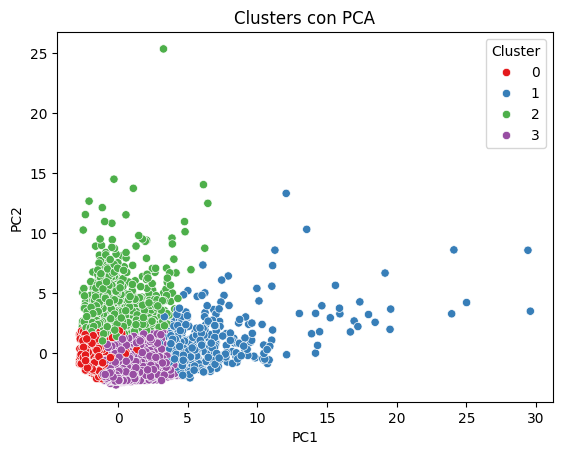

Varianza total explicada: 0.4761145096128464


In [30]:
# PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.title('Clusters con PCA')
plt.show()

print("Varianza total explicada:", sum(pca.explained_variance_ratio_))

Se decidio utilizar el algoritmo K-Means para el agrupamiento. Esta elección se fundamenta en las siguientes razones:
* Tamaño del dataset: el dataset cuenta con aproximadamente 8,950 registros y K-Means es conocido por su eficiencia computacional en datasets de este orden de magnitud.
* Naturaleza de los datos: Las variables que describen el comportamiento financiero de los clientes son inherentemente continuas y tienden a formar grupos esféricos o convexos en el espacio de características. K-Means asume precisamente este tipo de geometría en los clusters, lo que se alinea bien con la naturaleza esperada de los segmentos de clientes.
* Interpretabilidad: K-Means produce clusters donde cada punto pertenece exactamente a un grupo, y el centroide de cada cluster representa el "cliente promedio" de ese segmento.

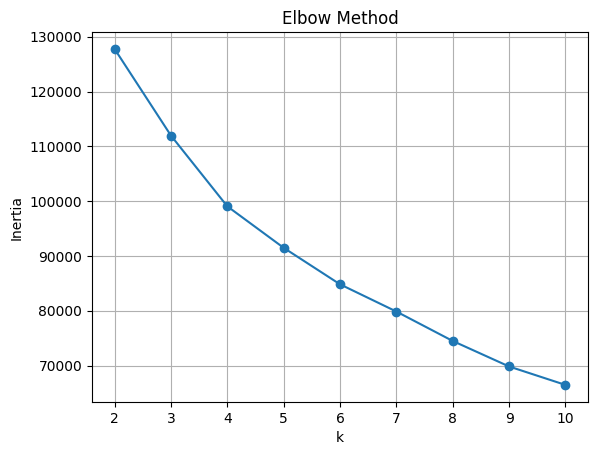

In [31]:
# ELBOW METHOD

from sklearn.cluster import KMeans

inertias = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.grid()
plt.show()

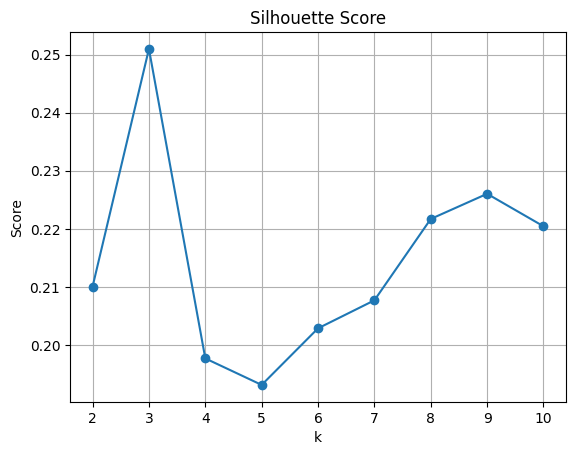

In [32]:
# SILHOUETTE

from sklearn.metrics import silhouette_score

sil_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K, sil_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')
plt.grid()
plt.show()

In [33]:
# METRICAS

from sklearn.metrics import davies_bouldin_score

sil = silhouette_score(X_scaled, clusters)
db = davies_bouldin_score(X_scaled, clusters)

print(f"Silhouette Score: {sil:.3f}")
print(f"Davies-Bouldin Index: {db:.3f}")

Silhouette Score: 0.198
Davies-Bouldin Index: 1.575


* Coeficiente de Silueta (0.198): Esta métrica combina la cohesión intra-cluster y la separación inter-cluster, con un rango de -1 a +1. El valor de 0.198 se encuentra por debajo de 0.25, lo que indica que los clusters presentan un grado significativo de traslape. Según la literatura (Kaufman & Rousseeuw, 1990), valores en este rango sugieren una estructura de clustering débil. Esto es esperable en datos del mundo real como el comportamiento financiero de clientes, donde las transiciones entre segmentos son graduales en lugar de abruptas.

* Índice de Davies-Bouldin (1.575): Esta métrica evalúa la relación entre dispersión intra-cluster y separación inter-cluster, donde valores más bajos indican mejor clustering. Nuestro valor de 1.575 es relativamente moderado, confirmando que los clusters no son perfectamente compactos ni están extremadamente separados.


La combinación de ambas métricas revela que los clusters están parcialmente traslapados. Sin embargo, esto no invalida la segmentación para fines prácticos, ya que incluso diferenciaciones parciales pueden informar estrategias de marketing diferenciadas. La naturaleza continua del comportamiento financiero hace esperable cierto grado de ambigüedad en los límites entre segmentos.


La caracterización de cada cluster traduce hallazgos técnicos en conocimiento accionable. Implementamos este análisis mediante:
* Agregación de medias por cluster: se calcula la media de todas las variables originales para cada cluster, permitiendo interpretar los resultados en unidades originales.
* Identificación de rasgos distintivos: Para cada cluster, se identifican las 5 variables con valores medios más altos.

In [34]:
# Caracterizacion de clusters

cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
display(cluster_summary)

for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster}")
    display(cluster_summary.loc[cluster].sort_values(ascending=False).head(5))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.710597,974.260054,569.001764,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1985.036426,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2020.801857,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,646.019774,0.269258,11.594595



Cluster 0


,0
CREDIT_LIMIT,3278.710597
BALANCE,1012.658327
PAYMENTS,974.260054
CASH_ADVANCE,596.509903
MINIMUM_PAYMENTS,569.001764



Cluster 1


,1
CREDIT_LIMIT,9696.943765
PURCHASES,7681.620098
PAYMENTS,7288.739497
ONEOFF_PURCHASES,5095.878826
BALANCE,3551.153761



Cluster 2


,2
CREDIT_LIMIT,7546.160857
BALANCE,4602.449658
CASH_ADVANCE,4521.509581
PAYMENTS,3484.054216
MINIMUM_PAYMENTS,2020.801857



Cluster 3


,3
CREDIT_LIMIT,4213.207678
PAYMENTS,1332.194205
PURCHASES,1236.178934
BALANCE,894.907458
MINIMUM_PAYMENTS,646.019774


A partir de la aplicación del algoritmo K-Means sobre el dataset de clientes de tarjeta de crédito, se identificaron 4 segmentos de clientes con perfiles de comportamiento financiero claramente diferenciados. La elección de k=4 fue validada mediante el método del codo y el coeficiente de silueta, aunque este último arrojó un valor de 0.198, indicando que los clusters presentan cierto grado de traslape.